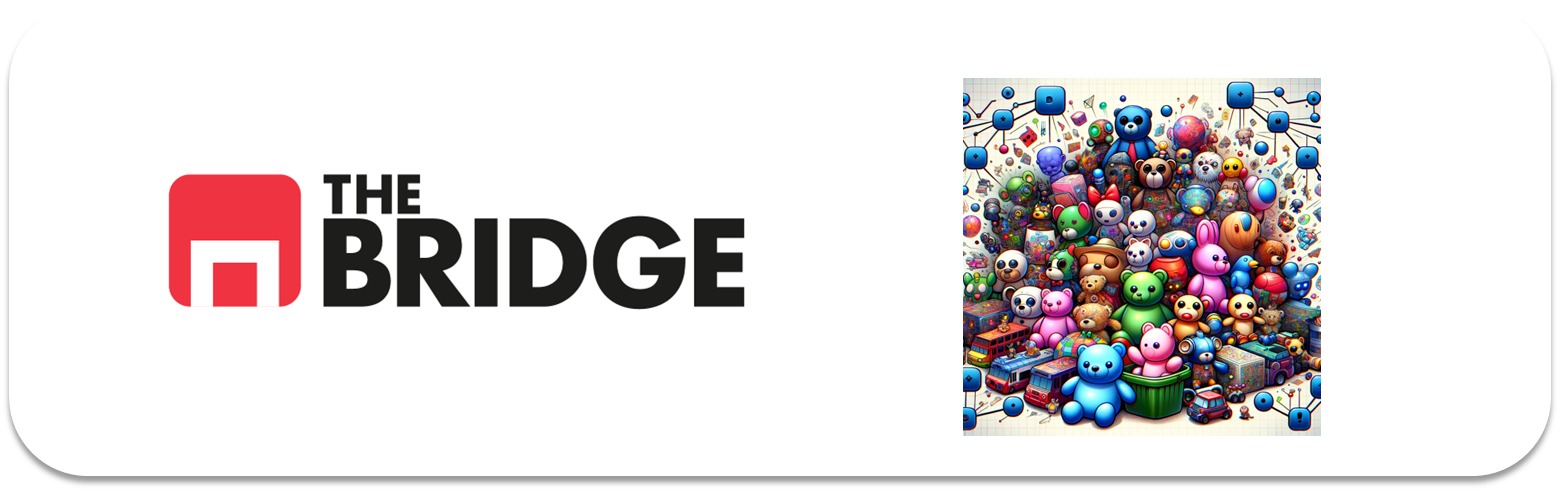

## PRACTICA OBLIGATORIA: **DBSCAN y Clustering Jerárquico**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado aplicado a clustering jerárquico y no jerárquico. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
import scipy.cluster.hierarchy as shc

### Parte I. Modelado

#### Descripción del problema.

En una planta de experimentación con nuevas bebidas energéticas están trabajando con diferentes mezclas de componentes para obtener posibles variedades de su producto estrella "NonstopU". El problema es que la fabricación de cada "prototipo" conlleva demasiado tiempo y las pruebas de sabores y de propiedades "non-stop" antisueño y antifatiga son costosas.  

En ese sentido quieren construir algún sistema de segmentación previa de mezclas sin probarlas solo indicando las cantidades de cada componente de la bebida. Tienen datos pero desgraciadamente de mezclas anteriores con diferentes medidas pero que por temas presupuestarios y de prioridad no se hicieron test con usuarios y potenciales clientes, es decir no tienen un target de capacidad antifatiga o de preferncia del usuario que puedas servirles para construir un clasificador clásico como han hecho otras veces.  

Han acudido a vosotros con la necesida de encontrar ese segmentador de posibles bebidas y con los datos de las mezclas no probadas anteriores por ver si vostros podéis ayudarles a encontrar algún tipo de segmentación que luego ello se encargarían de interpretar. No es requisito obligatorio pero les gustaría también poder establecer algún tipo de relación entre las segmentaciones (tipo cuales segmentos se "parecerían" más entre sí)

NOTA ORIENTATIVA: Los químicos no esperan que haya menos de 3 segmentos ni más de 5.  
NOTA OPERATIVA: El dataset con los datos que nos han dado los químicos está en "./data/empowering_drinks.csv"

**Se pide**: Construir al menos dos algoritmos de clustering (DBSCAN debe ser uno de ellos y el otro debería estar claro cual deberíamos usar dado el enunciado). Compararlos brevemente aunque sea meramente especulativo (¿Por qué es espculativo?)

**Se recomienda**: Visualizar las features dos a dos para escoger las mejores, no necesariamente hay que usar todas, ni tampoco quedarse en dos. Probar diferentes hiperparámetros en función de la nota orientativa y explicar porqué se han escogido los que finalmente se hayan escogido. 

Recuerda que el proceso es similar a lo que vimos en el otro tipo de aprendizaje:
1. Entender el problema
2. Cargar datos, visualizar.
3. MiniEDA: Selección de features
4. Tratamiento de Features.
5. Selección de modelos, selección de hiperparámetros
6. Entrenamiento, visualización de resultados.
7. Discusión de los mismos


Shape: (153, 5)

Primeras filas:
   Azúcares  Vitamínas del grupo B   Cafeína  Ácido Cítrico   Taurina
0  1.518613               0.232053  1.034819       1.013009  0.251717
1  0.246290              -0.827996  0.733629       0.965242 -0.293321
2  0.196879               1.109334  1.215533       1.395148  0.269020
3  1.691550               0.487926  1.466525       2.334574  1.186068
4  0.295700               1.840403  0.663351      -0.037874 -0.319276

Estadísticas descriptivas:
         Azúcares  Vitamínas del grupo B     Cafeína  Ácido Cítrico  \
count  153.000000             153.000000  153.000000     153.000000   
mean     0.019231               0.037273    0.041057       0.080022   
std      1.026182               0.995984    1.040928       1.009450   
min     -2.434235              -3.679162   -1.695971      -1.493188   
25%     -0.816038              -0.499016   -1.043392      -0.738463   
50%      0.061000              -0.023821    0.211566      -0.165254   
75%      0.876275     

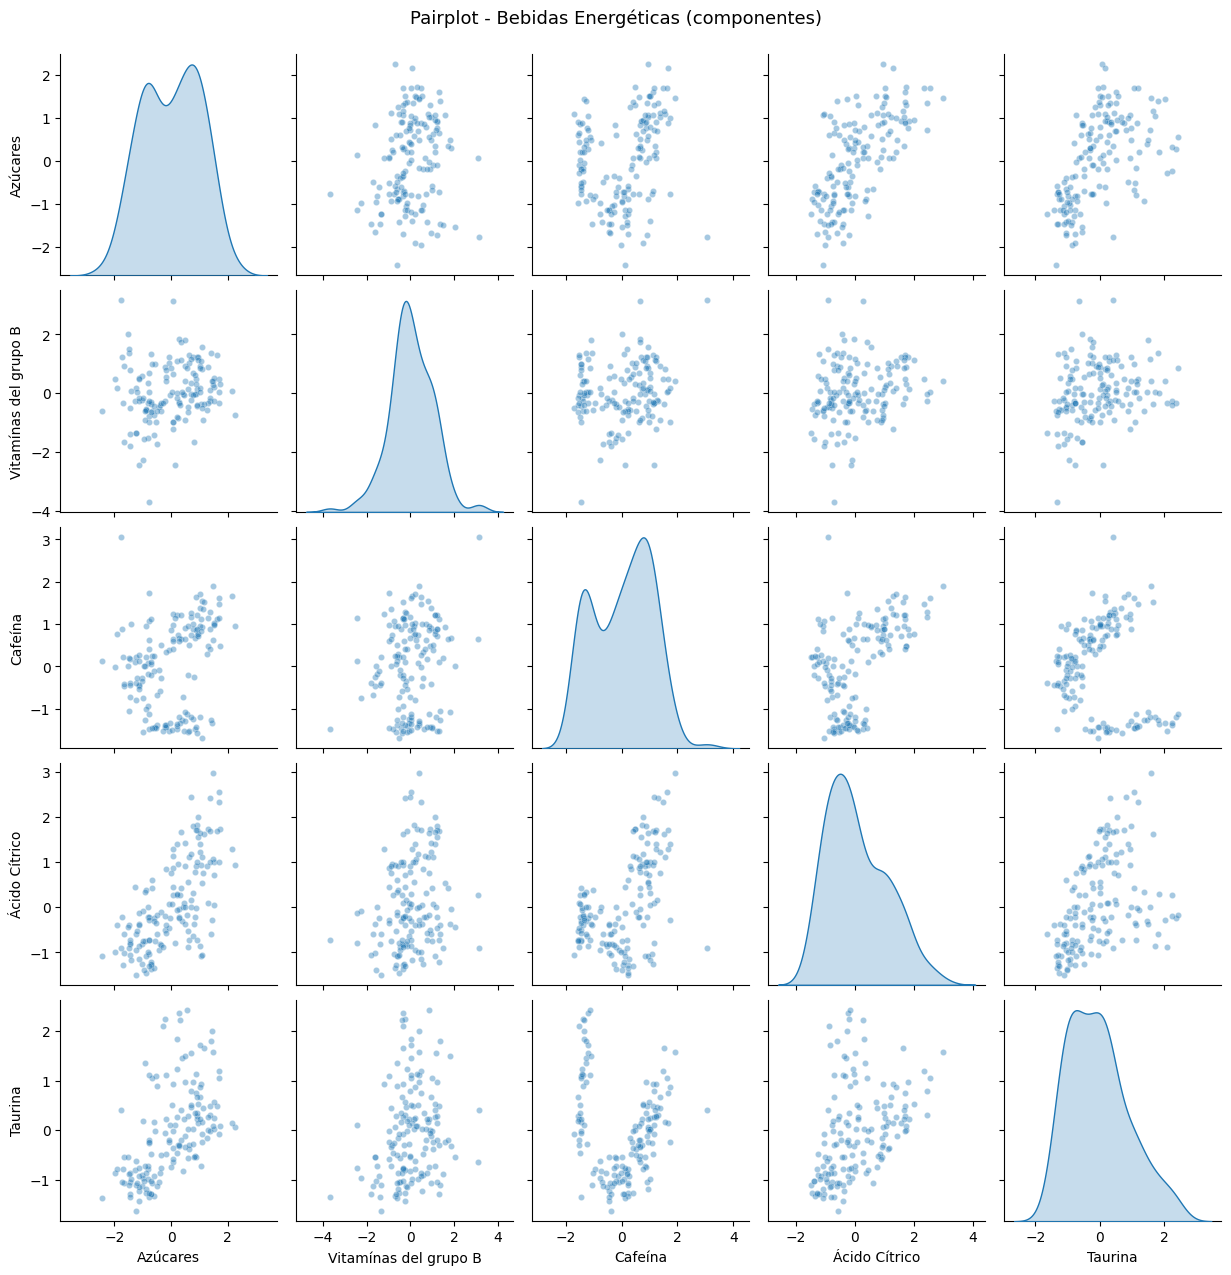

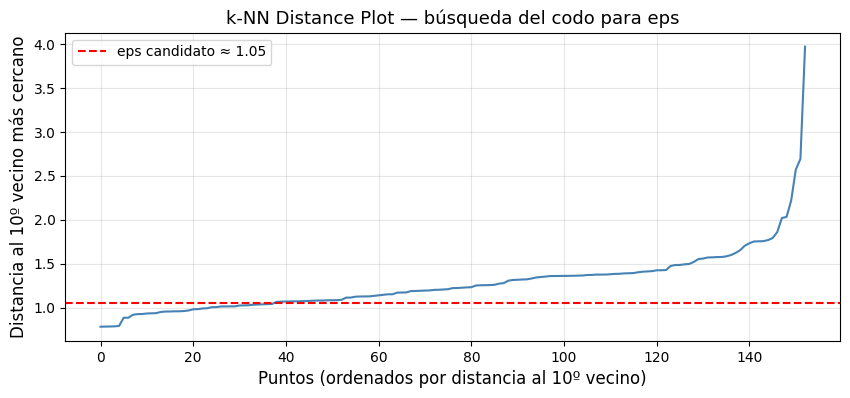

El codo se sitúa aproximadamente en distancia ≈ 1.05

Exploración de hiperparámetros DBSCAN:
  eps   ms  clusters  outliers%
 0.80    5         8       52.3%
 0.80   10         2       81.7%
 1.00    5         3       18.3%
 1.00   10         2       57.5%
 1.05    5         3        9.8%
 1.05   10         3       38.6%
 1.20    5         1        5.2%
 1.20   10         3       14.4%
 1.50    5         1        2.6%
 1.50   10         1        2.6%

DBSCAN final (eps=1.05, min_samples=5):
  Clusters encontrados: 3
  Outliers (ruido):     15 (9.8%)
  Distribución de etiquetas: {np.int64(-1): np.int64(15), np.int64(0): np.int64(54), np.int64(1): np.int64(48), np.int64(2): np.int64(36)}
  Silhouette score (sin outliers): 0.4263


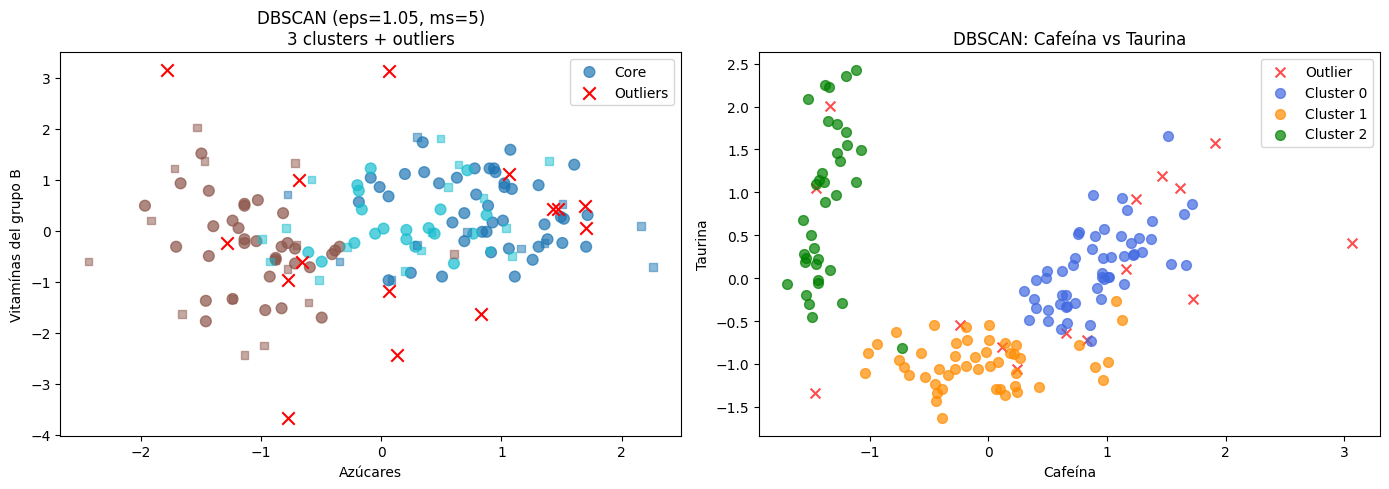

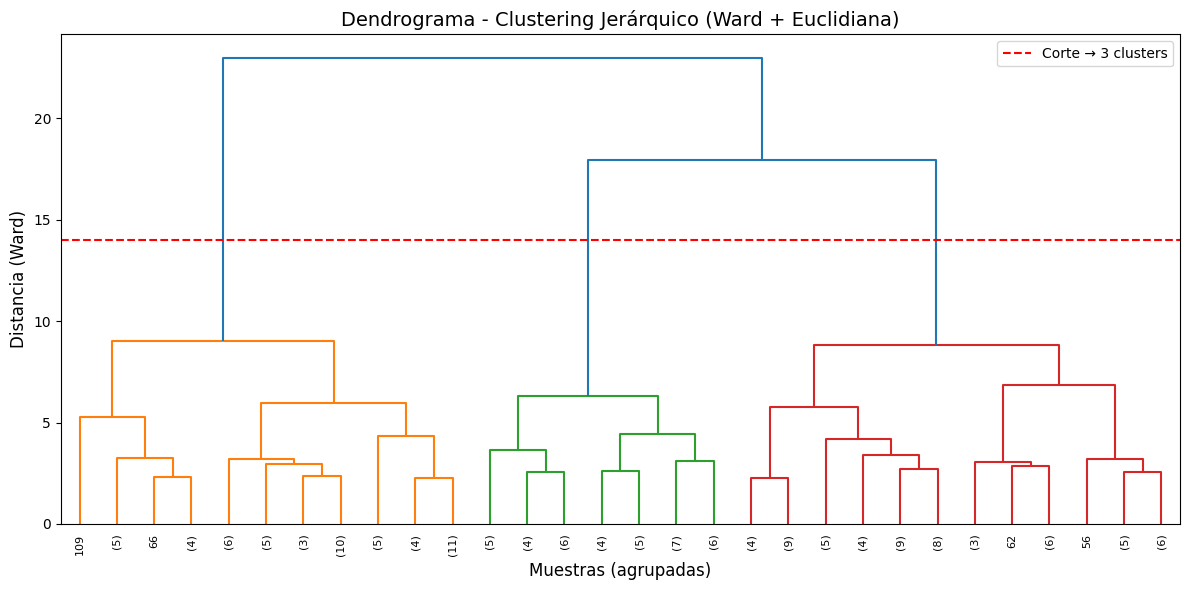

Lectura del dendrograma:
  El mayor salto (gap) entre fusiones se produce antes de k=3.
  Elegimos k=3 clusters, consistente con la nota orientativa (3-5 segmentos).
  AgglomerativeClustering k=3 → silhouette=0.3843
  AgglomerativeClustering k=4 → silhouette=0.3369
  AgglomerativeClustering k=5 → silhouette=0.3037

AgglomerativeClustering final: k=3, silhouette=0.3843
Distribución: {np.int64(0): np.int64(55), np.int64(1): np.int64(61), np.int64(2): np.int64(37)}


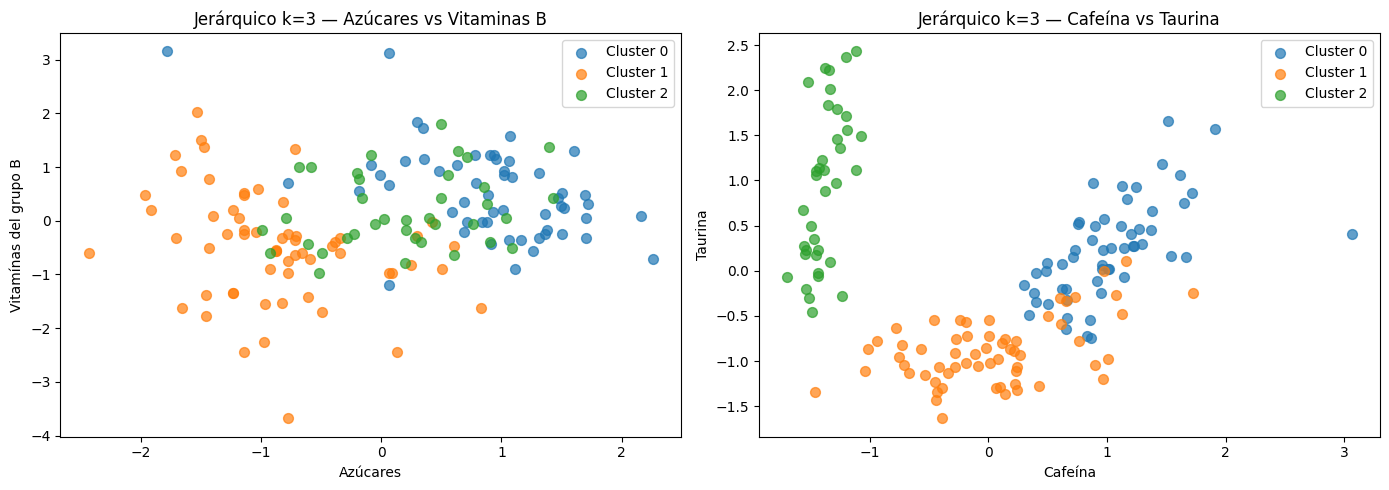


Media por cluster (AgglomerativeClustering k=3):
             Azúcares  Vitamínas del grupo B  Cafeína  Ácido Cítrico  Taurina
cluster_agg                                                                  
0               0.892                  0.520    1.021          1.102    0.231
1              -0.873                 -0.491    0.021         -0.609   -0.884
2               0.193                  0.190   -1.383         -0.303    0.933

Comparación breve:
  DBSCAN: detecta 3 clusters + identifica outliers/ruido como clase -1.
          Es especulativa porque no sabemos si los outliers son errores o mezclas extremas.
  Jerárquico: asigna TODOS los puntos a un cluster, estructura jerárquica
              visible en el dendrograma. El resultado es determinista.
  Ambos convergen en 3 segmentos, lo que refuerza la segmentación en 3 grupos.


In [2]:
# =============================================================================
# PARTE I: MODELADO
# =============================================================================

# --- 1. Cargar datos ---
df = pd.read_csv('./data/empowering_drinks.csv', sep='|')
print(f"Shape: {df.shape}")
print("\nPrimeras filas:")
print(df.head())
print("\nEstadísticas descriptivas:")
print(df.describe())

# Los datos ya están estandarizados (media ≈ 0, std ≈ 1)
# No es necesario volver a escalar

# --- 2. EDA: visualización pairplot ---
print("\nPairplot de las features (buscamos posibles agrupaciones visuales)...")
sns.pairplot(df, diag_kind='kde', plot_kws={'alpha': 0.4, 's': 20})
plt.suptitle("Pairplot - Bebidas Energéticas (componentes)", y=1.02, fontsize=13)
plt.show()

# --- 3. Análisis k-NN para determinar eps (DBSCAN) ---
X = df.values
k_nn = 2 * X.shape[1]  # regla: 2 * número de features = 10
nn = NearestNeighbors(n_neighbors=k_nn)
nn.fit(X)
distances, _ = nn.kneighbors(X)
dist_sorted = np.sort(distances[:, -1])

plt.figure(figsize=(10, 4))
plt.plot(dist_sorted, color='steelblue')
plt.xlabel("Puntos (ordenados por distancia al 10º vecino)", fontsize=12)
plt.ylabel(f"Distancia al {k_nn}º vecino más cercano", fontsize=12)
plt.title("k-NN Distance Plot — búsqueda del codo para eps", fontsize=13)
plt.axhline(y=1.05, color='red', linestyle='--', label='eps candidato ≈ 1.05')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print("El codo se sitúa aproximadamente en distancia ≈ 1.05")

# --- 4. DBSCAN: exploración de hiperparámetros ---
print("\nExploración de hiperparámetros DBSCAN:")
print(f"{'eps':>5}  {'ms':>3}  {'clusters':>8}  {'outliers%':>9}")
for eps in [0.8, 1.0, 1.05, 1.2, 1.5]:
    for ms in [5, 10]:
        db = DBSCAN(eps=eps, min_samples=ms).fit(X)
        n_cl = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
        pct = (db.labels_ == -1).sum() / len(db.labels_) * 100
        print(f"{eps:>5.2f}  {ms:>3}  {n_cl:>8}  {pct:>9.1f}%")

# Elección justificada: eps=1.05, min_samples=5
# → 3 clusters (dentro del rango 3-5 esperado), ~10% outliers (aceptable)
# min_samples=5 porque el dataset es pequeño (153 muestras)

# --- 5. DBSCAN final ---
eps_final = 1.05
ms_final = 5
dbscan = DBSCAN(eps=eps_final, min_samples=ms_final)
labels_dbscan = dbscan.fit_predict(X)

n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_outliers_db = (labels_dbscan == -1).sum()
print(f"\nDBSCAN final (eps={eps_final}, min_samples={ms_final}):")
print(f"  Clusters encontrados: {n_clusters_db}")
print(f"  Outliers (ruido):     {n_outliers_db} ({n_outliers_db/len(labels_dbscan)*100:.1f}%)")
print(f"  Distribución de etiquetas: {dict(zip(*np.unique(labels_dbscan, return_counts=True)))}")

# Silhouette (solo sobre puntos no outliers)
mask_no_noise = labels_dbscan != -1
if mask_no_noise.sum() > 1 and n_clusters_db > 1:
    sil_db = silhouette_score(X[mask_no_noise], labels_dbscan[mask_no_noise])
    print(f"  Silhouette score (sin outliers): {sil_db:.4f}")

# --- 6. Visualización DBSCAN (primeras 2 features) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter coloreado por cluster
core_mask = np.zeros(len(labels_dbscan), dtype=bool)
core_mask[dbscan.core_sample_indices_] = True
noise_mask = labels_dbscan == -1
non_core_mask = ~(core_mask | noise_mask)

ax = axes[0]
scatter = ax.scatter(X[core_mask, 0], X[core_mask, 1],
                     c=labels_dbscan[core_mask], cmap='tab10', marker='o',
                     s=60, label='Core', alpha=0.7)
ax.scatter(X[non_core_mask, 0], X[non_core_mask, 1],
           c=labels_dbscan[non_core_mask], cmap='tab10', marker='s',
           s=30, alpha=0.5)
ax.scatter(X[noise_mask, 0], X[noise_mask, 1],
           c='red', marker='x', s=80, label='Outliers', zorder=5)
ax.set_xlabel(df.columns[0])
ax.set_ylabel(df.columns[1])
ax.set_title(f"DBSCAN (eps={eps_final}, ms={ms_final})\n{n_clusters_db} clusters + outliers")
ax.legend()

# Pairplot DBSCAN simplificado (Cafeína vs Azúcares)
ax2 = axes[1]
colors_db = {-1: 'red', 0: 'royalblue', 1: 'darkorange', 2: 'green', 3: 'purple'}
for lbl in np.unique(labels_dbscan):
    mask = labels_dbscan == lbl
    lbl_str = f"Cluster {lbl}" if lbl != -1 else "Outlier"
    ax2.scatter(X[mask, 2], X[mask, 4],
                color=colors_db.get(lbl, 'gray'), label=lbl_str,
                s=50, alpha=0.7, marker='x' if lbl == -1 else 'o')
ax2.set_xlabel(df.columns[2])
ax2.set_ylabel(df.columns[4])
ax2.set_title("DBSCAN: Cafeína vs Taurina")
ax2.legend()
plt.tight_layout()
plt.show()

# =============================================================================
# CLUSTERING JERÁRQUICO
# =============================================================================

# --- 7. Dendrograma ---
plt.figure(figsize=(12, 6))
plt.title("Dendrograma - Clustering Jerárquico (Ward + Euclidiana)", fontsize=14)
clusters_hier = shc.linkage(X, method='ward', metric='euclidean')
shc.dendrogram(clusters_hier, truncate_mode='lastp', p=30,
               leaf_rotation=90, leaf_font_size=8)
plt.xlabel("Muestras (agrupadas)", fontsize=12)
plt.ylabel("Distancia (Ward)", fontsize=12)
# Línea de corte: mayor salto (gap) → k=3 clusters
plt.axhline(y=14, color='red', linestyle='--', label='Corte → 3 clusters')
plt.legend()
plt.tight_layout()
plt.show()

print("Lectura del dendrograma:")
print("  El mayor salto (gap) entre fusiones se produce antes de k=3.")
print("  Elegimos k=3 clusters, consistente con la nota orientativa (3-5 segmentos).")

# --- 8. AgglomerativeClustering ---
for k_agg in [3, 4, 5]:
    agg_tmp = AgglomerativeClustering(n_clusters=k_agg, linkage='ward')
    lbl_tmp = agg_tmp.fit_predict(X)
    sil_tmp = silhouette_score(X, lbl_tmp)
    print(f"  AgglomerativeClustering k={k_agg} → silhouette={sil_tmp:.4f}")

# k=3 tiene el mejor silhouette
k_final = 3
agg = AgglomerativeClustering(n_clusters=k_final, linkage='ward', metric='euclidean')
labels_agg = agg.fit_predict(X)
sil_agg = silhouette_score(X, labels_agg)
print(f"\nAgglomerativeClustering final: k={k_final}, silhouette={sil_agg:.4f}")
print(f"Distribución: {dict(zip(*np.unique(labels_agg, return_counts=True)))}")

# --- 9. Visualización clustering jerárquico ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
for lbl in np.unique(labels_agg):
    mask = labels_agg == lbl
    ax1.scatter(X[mask, 0], X[mask, 1], label=f"Cluster {lbl}", s=50, alpha=0.7)
ax1.set_xlabel(df.columns[0])
ax1.set_ylabel(df.columns[1])
ax1.set_title(f"Jerárquico k={k_final} — Azúcares vs Vitaminas B")
ax1.legend()

ax2 = axes[1]
for lbl in np.unique(labels_agg):
    mask = labels_agg == lbl
    ax2.scatter(X[mask, 2], X[mask, 4], label=f"Cluster {lbl}", s=50, alpha=0.7)
ax2.set_xlabel(df.columns[2])
ax2.set_ylabel(df.columns[4])
ax2.set_title(f"Jerárquico k={k_final} — Cafeína vs Taurina")
ax2.legend()
plt.tight_layout()
plt.show()

# --- 10. Interpretación por cluster ---
df_result = df.copy()
df_result['cluster_agg'] = labels_agg
df_result['cluster_dbscan'] = labels_dbscan

print("\nMedia por cluster (AgglomerativeClustering k=3):")
print(df_result.groupby('cluster_agg')[df.columns.tolist()].mean().round(3).to_string())

print("\nComparación breve:")
print("  DBSCAN: detecta 3 clusters + identifica outliers/ruido como clase -1.")
print("          Es especulativa porque no sabemos si los outliers son errores o mezclas extremas.")
print("  Jerárquico: asigna TODOS los puntos a un cluster, estructura jerárquica")
print("              visible en el dendrograma. El resultado es determinista.")
print("  Ambos convergen en 3 segmentos, lo que refuerza la segmentación en 3 grupos.")

### Parte II. Nuevos experimentos

Los químicos están muy esperanzados con los modelos que les habéis mostrado y os pasan una lista de nuevos experimentos para que los clasifiquéis. Emplea uno de los modelos construidos, el que te resulte más sencillo, para segmentar los nuevos experimentos que puedes encontrar en "./data/new_experiments.csv"


PARTE II: PREDICCIÓN DE NUEVOS EXPERIMENTOS
Nuevos experimentos shape: (6, 5)
   Azúcares  Vitamínas del grupo B   Cafeína  Ácido Cítrico   Taurina
0  1.481555               0.305159  1.366128       2.239039  0.731870
1  0.616869               0.890014  0.583034       0.312420 -0.665332
2 -1.680724               0.341713 -0.340615      -0.213021 -0.976782
3 -0.284874              -1.412851 -0.782361      -1.193845 -0.717240
4 -0.927212               0.634140 -1.565455      -0.085641 -0.522583
5  0.962743              -0.243142 -1.354622      -0.420013  1.956043

Cluster asignado a cada nuevo experimento: [0 0 1 1 2 2]

Probabilidades por cluster:
       Cluster 0  Cluster 1  Cluster 2
Exp_1        1.0        0.0        0.0
Exp_2        1.0        0.0        0.0
Exp_3        0.0        1.0        0.0
Exp_4        0.0        1.0        0.0
Exp_5        0.0        0.2        0.8
Exp_6        0.0        0.0        1.0


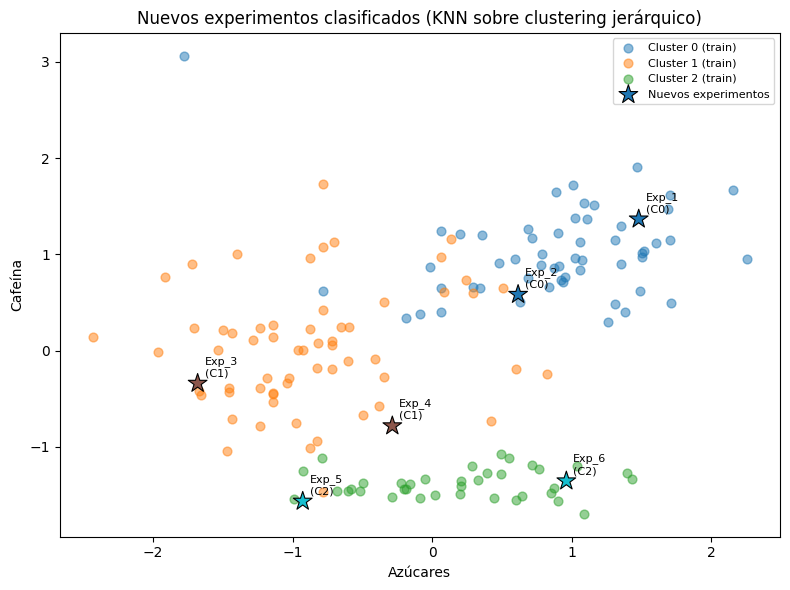

In [3]:
# =============================================================================
# PARTE II: NUEVOS EXPERIMENTOS
# =============================================================================

print("\n" + "="*60)
print("PARTE II: PREDICCIÓN DE NUEVOS EXPERIMENTOS")
print("="*60)

df_new = pd.read_csv('./data/new_experiments.csv', sep='|')
X_new = df_new.values
print(f"Nuevos experimentos shape: {X_new.shape}")
print(df_new.to_string())

# Usamos AgglomerativeClustering porque es más estable (DBSCAN no tiene .predict())
# Entrenamos un KNN sobre las etiquetas del clustering jerárquico
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X, labels_agg)

pred_new = knn.predict(X_new)
proba_new = knn.predict_proba(X_new)

print(f"\nCluster asignado a cada nuevo experimento: {pred_new}")
print("\nProbabilidades por cluster:")
print(pd.DataFrame(proba_new,
                   columns=[f"Cluster {c}" for c in knn.classes_],
                   index=[f"Exp_{i+1}" for i in range(len(pred_new))]).round(2).to_string())

# Visualización
fig, ax = plt.subplots(figsize=(8, 6))
for lbl in np.unique(labels_agg):
    mask = labels_agg == lbl
    ax.scatter(X[mask, 0], X[mask, 2],
               label=f"Cluster {lbl} (train)", s=40, alpha=0.5)
ax.scatter(X_new[:, 0], X_new[:, 2],
           c=pred_new, cmap='tab10', s=200, marker='*',
           edgecolors='black', linewidths=0.8, zorder=5,
           label='Nuevos experimentos')
for i, (p, lbl) in enumerate(zip(X_new, pred_new)):
    ax.annotate(f"Exp_{i+1}\n(C{lbl})", (p[0], p[2]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)
ax.set_xlabel(df.columns[0])
ax.set_ylabel(df.columns[2])
ax.set_title("Nuevos experimentos clasificados (KNN sobre clustering jerárquico)")
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

### Parte III. EXTRA (Voluntario): 6 meses después...

La unidad de experimentación recibió un presupuesto adicional gracias a los modelos que les proporcionastes e hizo pruebas con cliente y obtuvo resultados como para clasificar cada bebida en terminos de "energización" en tres niveles (1, media; 2, media-alta, 3, alta). El resultado de los mismos está en el fichero adecuado en el directorio data y alineado con los experimentos iniciales y al final con los nuevos experimentos de la parte anterior.

Evalua la segmentación de los modelos creados en la primera parte.


PARTE III EXTRA: EVALUACIÓN CON RESULTADOS REALES
power_results shape: (159, 1)
Distribución clases reales: {np.int64(1): np.int64(58), np.int64(2): np.int64(62), np.int64(3): np.int64(39)}

Distribución clusters predichos: {np.int64(0): np.int64(56), np.int64(1): np.int64(64), np.int64(2): np.int64(39)}

Tabla de contingencia:
Clase real (energización)   1   2   3
Cluster (predicho)                   
0                          53   3   0
1                           5  59   0
2                           0   0  39

Adjusted Rand Index (ARI): 0.8414
  ARI=1.0 → agrupación perfecta, ARI=0 → agrupación aleatoria
  ARI=0.841 indica buena concordancia
  La comparación es especulativa porque las etiquetas de cluster y de clase
  son independientes (el clustering no conoce la escala de energización).


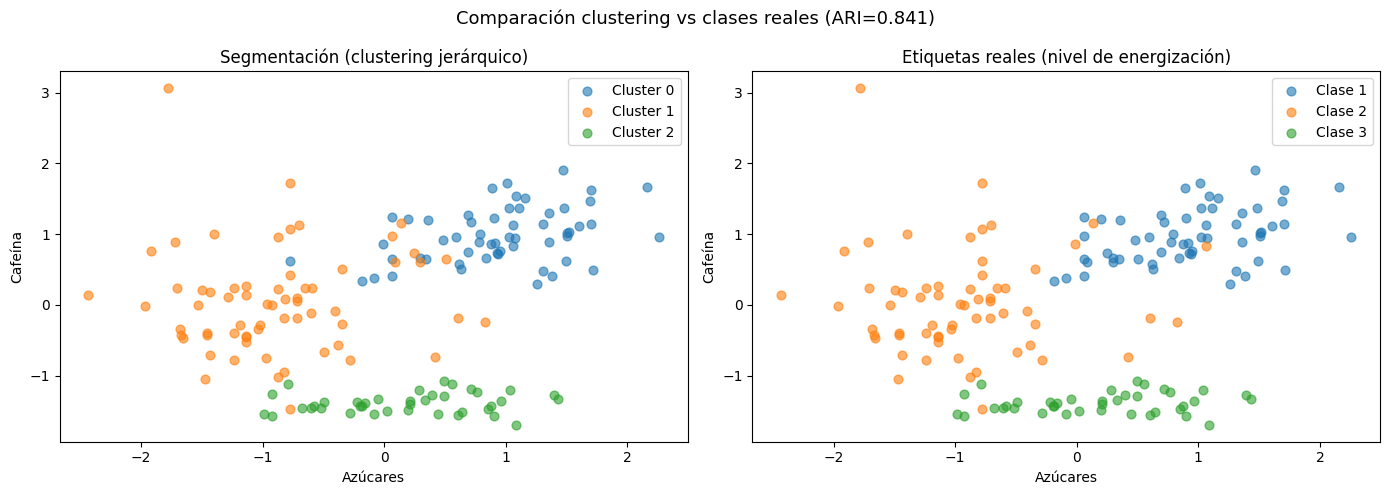

In [4]:


# =============================================================================
# PARTE III: EXTRA — 6 meses después (Evaluación con ground truth)
# =============================================================================

print("\n" + "="*60)
print("PARTE III EXTRA: EVALUACIÓN CON RESULTADOS REALES")
print("="*60)

df_power = pd.read_csv('./data/power_results.csv', sep='|')
y_true = df_power['class'].values
print(f"power_results shape: {df_power.shape}")
print(f"Distribución clases reales: {dict(zip(*np.unique(y_true, return_counts=True)))}")

# Predicciones para todo el conjunto (153 originales + 6 nuevos = 159)
X_all = np.vstack([X, X_new])
pred_all = knn.predict(X_all)

print(f"\nDistribución clusters predichos: {dict(zip(*np.unique(pred_all, return_counts=True)))}")

# Tabla de contingencia: clustering vs clases reales
df_eval = pd.DataFrame({'cluster': pred_all, 'clase_real': y_true})
contingencia = pd.crosstab(df_eval['cluster'], df_eval['clase_real'],
                           rownames=['Cluster (predicho)'],
                           colnames=['Clase real (energización)'])
print("\nTabla de contingencia:")
print(contingencia.to_string())

# Adjusted Rand Index
ari = adjusted_rand_score(y_true, pred_all)
print(f"\nAdjusted Rand Index (ARI): {ari:.4f}")
print("  ARI=1.0 → agrupación perfecta, ARI=0 → agrupación aleatoria")
print(f"  ARI={ari:.3f} indica {'buena' if ari > 0.4 else 'moderada'} concordancia")
print("  La comparación es especulativa porque las etiquetas de cluster y de clase")
print("  son independientes (el clustering no conoce la escala de energización).")

# Visualización de la comparación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
for lbl in np.unique(pred_all):
    mask = pred_all == lbl
    ax1.scatter(X_all[mask, 0], X_all[mask, 2],
                label=f"Cluster {lbl}", s=40, alpha=0.6)
ax1.set_xlabel(df.columns[0])
ax1.set_ylabel(df.columns[2])
ax1.set_title("Segmentación (clustering jerárquico)")
ax1.legend()

ax2 = axes[1]
for clase in np.unique(y_true):
    mask = y_true == clase
    ax2.scatter(X_all[mask, 0], X_all[mask, 2],
                label=f"Clase {clase}", s=40, alpha=0.6)
ax2.set_xlabel(df.columns[0])
ax2.set_ylabel(df.columns[2])
ax2.set_title("Etiquetas reales (nivel de energización)")
ax2.legend()

plt.suptitle(f"Comparación clustering vs clases reales (ARI={ari:.3f})", fontsize=13)
plt.tight_layout()
plt.show()